In [59]:
# 强制 TF 不使用 GPU
import tensorflow as tf

# 禁用所有 GPU
tf.config.set_visible_devices([], 'GPU')

# 关闭日志
tf.get_logger().setLevel('ERROR')

In [60]:
import csv

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

# 各パス指定

In [61]:
dataset = '/home/spring/hand/data/21point/all.csv'
model_save_path = 'model/keypoint_classifier/keypoint_classifier.hdf5'

# 分類数設定

In [62]:
NUM_CLASSES = 9

# 学習データ読み込み

In [63]:
X_dataset = np.loadtxt(dataset, delimiter=',', dtype='float32', usecols=list(range(1, (21 * 2) + 1)))

In [64]:
y_dataset = np.loadtxt(dataset, delimiter=',', dtype='int32', usecols=(0))

In [65]:
indices = np.arange(len(X_dataset))

In [66]:
X_dataset = X_dataset.reshape(-1, 21, 2)

In [67]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_dataset,
    y_dataset,
    indices,
    test_size=0.2,
    random_state=42,
    stratify=y_dataset
)

# モデル構築

In [68]:
import tensorflow as tf
from tensorflow.keras import layers, models

def focal_loss(gamma=2.0, alpha=0.25, num_classes=9):
    def loss(y_true, y_pred):
        # 压平成 (batch,)
        y_true_flat = tf.reshape(tf.cast(y_true, tf.int32), [-1])

        # one-hot -> (batch, 9)
        y_true_onehot = tf.one_hot(y_true_flat, depth=num_classes)

        ce = tf.keras.losses.categorical_crossentropy(
            y_true_onehot, y_pred
        )

        pt = tf.reduce_sum(y_true_onehot * y_pred, axis=-1)

        fl = alpha * tf.pow(1.0 - pt, gamma) * ce

        return tf.reduce_mean(fl)

    return loss

def se_block(x, ratio=8):
    channels = x.shape[-1]
    se = layers.GlobalAveragePooling1D()(x)
    se = layers.Dense(channels // ratio, activation='relu')(se)
    se = layers.Dense(channels, activation='sigmoid')(se)
    se = layers.Reshape((1, channels))(se)
    return layers.Multiply()([x, se])


def residual_block(x, filters):
    shortcut = x

    x = layers.Conv1D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv1D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)

    # 如果通道不一致，做投影
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, padding='same')(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)

    # 加 SE 注意力
    x = se_block(x)

    return x


def build_model():
    inputs = layers.Input(shape=(21, 2))

    # 初始特征提取
    x = layers.Conv1D(64, 3, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # 多尺度卷积（关键提升点）
    b1 = layers.Conv1D(64, 3, padding='same', activation='relu')(x)
    b2 = layers.Conv1D(64, 5, padding='same', activation='relu')(x)
    b3 = layers.Conv1D(64, 7, padding='same', activation='relu')(x)
    x = layers.Concatenate()([b1, b2, b3])

    # 残差块堆叠
    x = residual_block(x, 128)
    x = residual_block(x, 256)

    # Dropout防过拟合
    x = layers.SpatialDropout1D(0.2)(x)

    # 池化
    x = layers.GlobalAveragePooling1D()(x)

    # 全连接增强表达能力
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(9, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    return model


model = build_model()
model.summary()

Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_4 (InputLayer)        [(None, 21, 2)]              0         []                            
                                                                                                  
 conv1d_30 (Conv1D)          (None, 21, 64)               448       ['input_4[0][0]']             
                                                                                                  
 batch_normalization_18 (Ba  (None, 21, 64)               256       ['conv1d_30[0][0]']           
 tchNormalization)                                                                                
                                                                                                  
 re_lu_15 (ReLU)             (None, 21, 64)               0         ['batch_normalization_18

In [69]:
model.summary()  # tf.keras.utils.plot_model(model, show_shapes=True)

Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_4 (InputLayer)        [(None, 21, 2)]              0         []                            
                                                                                                  
 conv1d_30 (Conv1D)          (None, 21, 64)               448       ['input_4[0][0]']             
                                                                                                  
 batch_normalization_18 (Ba  (None, 21, 64)               256       ['conv1d_30[0][0]']           
 tchNormalization)                                                                                
                                                                                                  
 re_lu_15 (ReLU)             (None, 21, 64)               0         ['batch_normalization_18

In [70]:
# モデルチェックポイントのコールバック
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_save_path, verbose=1, save_weights_only=False)
# 早期打ち切り用コールバック
es_callback = tf.keras.callbacks.EarlyStopping(patience=20, verbose=1)

In [71]:
model.compile(
    optimizer='adam',
    loss=focal_loss(),
    metrics=['accuracy']
)

# モデル訓練

In [72]:
model.fit(
    X_train,
    y_train,
    epochs=150,
    batch_size=1024,
    validation_data=(X_test, y_test),
    callbacks=[cp_callback, es_callback]
)

Epoch 1/150
199/199 [==============================] - ETA: 0s - loss: 0.0980 - accuracy: 0.7595
Epoch 1: saving model to model/keypoint_classifier/keypoint_classifier.hdf5
199/199 [==============================] - 35s 167ms/step - loss: 0.0980 - accuracy: 0.7595 - val_loss: 0.5437 - val_accuracy: 0.1175
Epoch 2/150


/home/spring/anaconda3/envs/yolo12/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


199/199 [==============================] - ETA: 0s - loss: 0.0631 - accuracy: 0.8131
Epoch 2: saving model to model/keypoint_classifier/keypoint_classifier.hdf5
199/199 [==============================] - 33s 166ms/step - loss: 0.0631 - accuracy: 0.8131 - val_loss: 0.3489 - val_accuracy: 0.4192
Epoch 3/150
199/199 [==============================] - ETA: 0s - loss: 0.0594 - accuracy: 0.8249
Epoch 3: saving model to model/keypoint_classifier/keypoint_classifier.hdf5
199/199 [==============================] - 33s 165ms/step - loss: 0.0594 - accuracy: 0.8249 - val_loss: 0.0589 - val_accuracy: 0.8345
Epoch 4/150
199/199 [==============================] - ETA: 0s - loss: 0.0578 - accuracy: 0.8315
Epoch 4: saving model to model/keypoint_classifier/keypoint_classifier.hdf5
199/199 [==============================] - 33s 166ms/step - loss: 0.0578 - accuracy: 0.8315 - val_loss: 0.0632 - val_accuracy: 0.8165
Epoch 5/150
199/199 [==============================] - ETA: 0s - loss: 0.0567 - accuracy: 0

In [73]:
# モデル評価
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=1024)

50/50 [==============================] - 2s 37ms/step - loss: 0.0568 - accuracy: 0.8452


In [74]:
model = tf.keras.models.load_model(
    model_save_path,
    compile=False
)

In [75]:
# 推論テスト
predict_result = model.predict(np.array([X_test[0]]))
print(np.squeeze(predict_result))
print(np.argmax(np.squeeze(predict_result)))

1/1 [==============================] - 0s 137ms/step
[0.02512501 0.14068028 0.15445231 0.02883717 0.16919373 0.15143268
 0.16539755 0.16215205 0.00272925]
4


# 混同行列

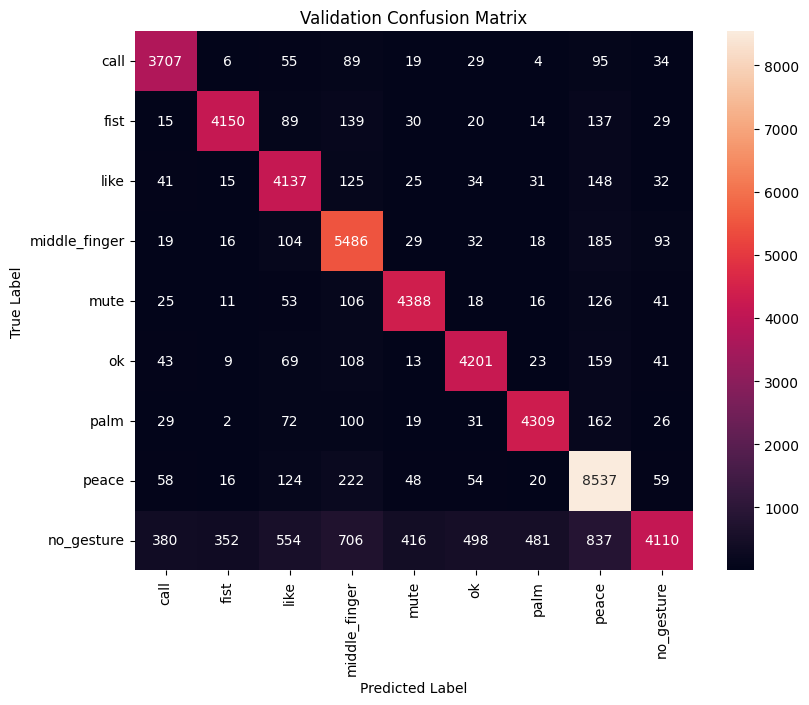

Classification Report
               precision    recall  f1-score   support

         call       0.86      0.92      0.89      4038
         fist       0.91      0.90      0.90      4623
         like       0.79      0.90      0.84      4588
middle_finger       0.77      0.92      0.84      5982
         mute       0.88      0.92      0.90      4784
           ok       0.85      0.90      0.88      4666
         palm       0.88      0.91      0.89      4750
        peace       0.82      0.93      0.87      9138
   no_gesture       0.92      0.49      0.64      8334

     accuracy                           0.85     50903
    macro avg       0.85      0.87      0.85     50903
 weighted avg       0.85      0.85      0.84     50903

误分类样本已保存到: /home/spring/hand/hand-gesture-recognition-using-mediapipe/run/middle_finger_no_gesture_confusion.csv


In [84]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import csv

from sklearn.metrics import confusion_matrix, classification_report


def print_confusion_matrix_and_save_errors(
    y_true,
    y_pred,
    y_pred_prob,
    idx_test,
    X_test,
    report=True,
    save_csv=True
):
    # 类别名称（按你的顺序）
    class_names = [
        "call",
        "fist",
        "like",
        "middle_finger",
        "mute",
        "ok",
        "palm",
        "peace",
        "no_gesture"
    ]

    labels = list(range(len(class_names)))

    # ======================
    # 1. 混淆矩阵
    # ======================
    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)

    df_cmx = pd.DataFrame(
        cmx_data,
        index=class_names,
        columns=class_names
    )

    plt.figure(figsize=(9, 7))
    sns.heatmap(df_cmx, annot=True, fmt='g')
    plt.title("Validation Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

    # ======================
    # 2. 分类报告
    # ======================
    if report:
        print("Classification Report")
        print(
            classification_report(
                y_true,
                y_pred,
                target_names=class_names
            )
        )

    # ======================
    # 3. 保存容易混淆类别
    # 重点：peace <-> palm
    # ======================
    if save_csv:
        save_path = "/home/spring/hand/hand-gesture-recognition-using-mediapipe/run/middle_finger_no_gesture_confusion.csv"

        with open(save_path, "w", newline="") as f:
            writer = csv.writer(f)

            # 表头
            writer.writerow([
                "test_id",
                "original_row_id",
                "true_label",
                "pred_label",
                "confidence"
            ] + [f"p{i}" for i in range(42)])

            for i in range(len(y_true)):
                # peace <-> palm 双向误分类
                if (
                    (y_true[i] == 8 and y_pred[i] == 3)
                    or
                    (y_true[i] == 3 and y_pred[i] == 8)
                ):
                    score = np.max(y_pred_prob[i])

                    # 展平成 42 维
                    points = X_test[i].reshape(-1).tolist()

                    writer.writerow([
                        i,
                        idx_test[i]+1,    
                        class_names[y_true[i]],
                        class_names[y_pred[i]],
                        round(float(score), 4)
                    ] + points)

        print(f"误分类样本已保存到: {save_path}")


# ======================
# 验证集预测
# ======================
Y_pred = model.predict(X_test, verbose=0)
y_pred = np.argmax(Y_pred, axis=1)

# ======================
# 画图 + 保存误分类
# ======================
print_confusion_matrix_and_save_errors(
     y_test,
    y_pred,
    Y_pred,
    idx_test,
    X_test
)

# Tensorflow-Lite用のモデルへ変換

In [77]:
# 推論専用のモデルとして保存
model.save(model_save_path, include_optimizer=False)

/home/spring/anaconda3/envs/yolo12/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [78]:
# モデルを変換(量子化)
tflite_save_path = 'model/keypoint_classifier/keypoint_classifier.tflite'

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

open(tflite_save_path, 'wb').write(tflite_quantized_model)
open(tflite_save_path, 'wb').write(tflite_quantized_model)

2026-04-10 10:28:50.151069: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-10 10:28:50.151093: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-10 10:28:50.151196: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp6r4x5k0j
2026-04-10 10:28:50.155316: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-10 10:28:50.155330: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp6r4x5k0j
2026-04-10 10:28:50.163424: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-10 10:28:50.221230: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmp6r4x5k0j
2026-04-10 10:28:50.243165: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 91968 m

705096

# 推論テスト

In [79]:
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

In [80]:
# 入出力テンソルを取得
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [81]:
interpreter.set_tensor(input_details[0]['index'], np.array([X_test[0]]))

In [82]:
%%time
# 推論実施
interpreter.invoke()
tflite_results = interpreter.get_tensor(output_details[0]['index'])

CPU times: user 1.75 ms, sys: 0 ns, total: 1.75 ms
Wall time: 1.56 ms


In [83]:
print(np.squeeze(tflite_results))
print(np.argmax(np.squeeze(tflite_results)))

[0.02484092 0.13907836 0.15628701 0.0300903  0.16950315 0.14671855
 0.16761412 0.1634162  0.00245139]
4
